<a href="https://colab.research.google.com/github/vesmunger/demo/blob/main/pochon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Initial Setup and Tool Installation

This cell is crucial for setting up the development environment. It installs all necessary Python libraries for natural language processing, audio handling, and data manipulation. This includes `transformers` for advanced AI models, `soundfile` for audio operations, and `pandas` for data handling. It also verifies that the GPU is ready, which is essential for accelerating AI model computations.

In [ ]:
# Install Transformers for the Brain, SoundFile for the Voice
!pip install transformers datasets soundfile accelerate -q
# Install tools to handle Pokot Bible data
!pip install pandas pyarrow rustbpe tiktoken -q

import torch
import pandas as pd
import io
import requests
from IPython.display import Audio, display

print("✅ Tools Installed. GPU Ready:", torch.cuda.get_device_name(0))

✅ Tools Installed. GPU Ready: Tesla T4


### Loading and Inspecting the Kalenjin-Kiswahili Parallel Corpus

This cell handles the loading of the primary dataset, the Kalenjin-Kiswahili Parallel Corpus, from a CSV file. It ensures the file is located, loaded correctly using `pandas`, and inspects the column names to verify the presence of 'Kalenjin' and 'Kiswahili' text. This step is vital for accessing and preparing the linguistic data that will be used for translation and text-to-speech tasks.

In [ ]:
import pandas as pd
import os

# 1. Locate the file
# When you upload to Colab's sidebar, the path is usually just the filename
file_path = '/content/Kalenjin-Kiswahili-Parallel-Corpus.csv'

if os.path.exists(file_path):
    # 2. Load the CSV
    # We use 'utf-8' encoding to ensure Kalenjin special characters aren't garbled
    # The previous attempt failed due to a UnicodeDecodeError, so trying 'latin1' encoding.
    df_kln = pd.read_csv(file_path, encoding='latin1')

    # 3. Inspect the columns
    # Sometimes datasets use 'Kiswahili' or 'sw', let's check what yours uses
    print("Columns found in your file:", df_kln.columns.tolist())

    # 4. Extract the Kalenjin text
    # Assuming the column is named 'Kalenjin' based on the Zenodo record
    if 'Kalenjin' in df_kln.columns:
        kalenjin_sentences = df_kln['Kalenjin'].dropna().astype(str).tolist()
        print(f"✅ Success! Loaded {len(kalenjin_sentences)} Kalenjin sentences.")

        # Display the first 3 pairs to verify quality
        print("\n--- Modern Kalenjin Samples ---")
        for i in range(3):
            sw = df_kln.iloc[i]['Kiswahili'] if 'Kiswahili' in df_kln.columns else "N/A"
            kln = kalenjin_sentences[i]
            print(f"Swahili: {sw}")
            print(f"Kalenjin: {kln}\n")
    else:
        print("❌ Error: The column name might be different. Please check the printout above.")
else:
    print(f"❌ Error: File '{file_path}' not found. Did you upload it to the folder icon on the left?")

Columns found in your file: ['Kalenjin', 'Kiswahili']
✅ Success! Loaded 35119 Kalenjin sentences.

--- Modern Kalenjin Samples ---
Swahili: Nchini Kenya ina wanafunzi wengi katika shule ya msingi.
Kalenjin: emet ab kenya kotinye kipsomanink chechang en sukulit nemii ingweng

Swahili: Hakuna safari bila kuvuka mitihani ngumu.
Kalenjin: Mami panda ne makisirei tiemutik che koromen

Swahili: mbona unaongea sana, kwani huwezi kunyamaza?
Kalenjin: ichome ing'ololi mising, tos mengen isis?



### Random Sentence Selection and Text-to-Speech (TTS) Initialization

This cell selects a random Kalenjin sentence from the loaded dataset for demonstration. More importantly, it initializes a Text-to-Speech (TTS) pipeline using the `transformers` library, specifically a Swahili model, to convert text into spoken audio. The `speak_pokot` function is defined here, which will be used throughout the notebook to generate and play audio. This function is fundamental for demonstrating the 'speaking' capability of the AI.

In [ ]:
# Select a random modern sentence from your Zenodo file
import random
random_verse = random.choice(kalenjin_sentences)

print(f"AI is now speaking modern Kalenjin: {random_verse}")

# This uses the 'speak_pokot' function we defined in the previous cell
# NameError: name 'speak_pokot' is not defined
# The error occurred because the function 'speak_pokot' was called but had not been defined in any preceding cell.
# To fix this, we need to define the 'speak_pokot' function.
# Based on earlier installations, it's intended to use a Text-to-Speech (TTS) model from the transformers library.

from transformers import pipeline
import soundfile as sf
from IPython.display import Audio, display
import uuid # Import uuid for unique filenames

# Initialize the text-to-speech pipeline if not already done.
# Using 'facebook/mms-tts-swh' (Swahili) as a representative East African language TTS model.
# This model will be downloaded the first time it's run and might take some time.
# We store the synthesizer in a global variable to avoid re-initializing it on subsequent runs.
if 'tts_synthesizer' not in globals():
    print("Initializing text-to-speech model... (This may take a moment and download a model)")
    try:
        tts_synthesizer = pipeline("text-to-speech", model="facebook/mms-tts-swh")
        print("Text-to-speech model initialized.")
    except Exception as e:
        print(f"❌ Error initializing TTS model: {e}")
        tts_synthesizer = None # Set to None if initialization fails

def speak_pokot(text_to_speak, audio_filename=None):
    if tts_synthesizer is None:
        print(f"⚠️ TTS model not initialized. Cannot speak: {text_to_speak}")
        return
    try:
        # Generate speech
        speech = tts_synthesizer(text_to_speak)

        # Save to a unique temporary file to avoid overwriting
        if audio_filename is None:
            audio_filename = f"audio_{uuid.uuid4()}.wav"
        sf.write(audio_filename, speech["audio"], samplerate=speech["sampling_rate"])

        # Display the audio
        display(Audio(audio_filename, autoplay=True))
        print(f"✅ Speaking: {text_to_speak}")
    except Exception as e:
        print(f"❌ Error during speech synthesis: {e}")
        print(f"Could not speak: {text_to_speak}")

speak_pokot(random_verse, audio_filename='kalenjin_random_verse.wav')


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


AI is now speaking modern Kalenjin: ya mising koroi


✅ Speaking: ya mising koroi


### Speaking Corresponding Kiswahili and Kalenjin Sentences

Building upon the previous steps, this cell retrieves the Kiswahili translation for the randomly selected Kalenjin sentence. It then uses the `speak_pokot` function to audibly present both the Kiswahili and the Kalenjin sentences. This demonstrates the parallel nature of the corpus and the TTS model's ability to vocalize different languages, highlighting the project's goal of cross-lingual communication.

In [ ]:
# Get the Kalenjin sentence (already randomly selected in the previous cell)
kalenjin_sentence = random_verse

# Find the index of this Kalenjin sentence in the original DataFrame
# We need to ensure the sentence exists in the DataFrame to find its pair
# Convert both series to string type before comparison to avoid potential type issues
matching_row = df_kln[df_kln['Kalenjin'].astype(str) == kalenjin_sentence]

if not matching_row.empty:
    kiswahili_sentence = matching_row['Kiswahili'].iloc[0]

    print(f"\n--- Now speaking Kiswahili ---")
    print(f"Kiswahili: {kiswahili_sentence}")
    speak_pokot(kiswahili_sentence)

    print(f"\n--- Now speaking Kalenjin (with Swahili accent) ---")
    print(f"Kalenjin: {kalenjin_sentence}")
    speak_pokot(kalenjin_sentence)
else:
    print(f"❌ Error: Could not find the corresponding Kiswahili sentence for: {kalenjin_sentence}")



--- Now speaking Kiswahili ---
Kiswahili: Huu ugonjwa ni mbaya.


✅ Speaking: Huu ugonjwa ni mbaya.

--- Now speaking Kalenjin (with Swahili accent) ---
Kalenjin: ya mising koroi


✅ Speaking: ya mising koroi


### Displaying the First Five Sentence Pairs

This cell provides a quick overview of the dataset by displaying the first five Kalenjin-Kiswahili sentence pairs. This is important for a quick visual inspection of the data format and content, allowing users to verify that the corpus was loaded correctly and is suitable for the intended tasks.

In [ ]:
print("--- First 5 Kalenjin-Kiswahili Sentence Pairs ---")
for i in range(5):
    kalenjin_sentence = df_kln.loc[i, 'Kalenjin']
    kiswahili_sentence = df_kln.loc[i, 'Kiswahili']
    print(f"Kalenjin: {kalenjin_sentence}")
    print(f"Kiswahili: {kiswahili_sentence}\n")

--- First 5 Kalenjin-Kiswahili Sentence Pairs ---
Kalenjin: emet ab kenya kotinye kipsomanink chechang en sukulit nemii ingweng
Kiswahili: Nchini Kenya ina wanafunzi wengi katika shule ya msingi.

Kalenjin: Mami panda ne makisirei tiemutik che koromen
Kiswahili: Hakuna safari bila kuvuka mitihani ngumu.

Kalenjin: ichome ing'ololi mising, tos mengen isis?
Kiswahili: mbona unaongea sana, kwani huwezi kunyamaza?

Kalenjin: Anani ngalek che kibiit eng sebenyo
Kiswahili: Nikakumbuka mambo yaliyotukia kwa maisha yetu

Kalenjin:  Kikinyoru kipsomaninik oeng komiansiot eng sukul
Kiswahili:  Wanafunzi wawili walipatikana wakiwa wagonjwa shuleni.



### Speaking a Specific Sentence Pair by Index

This cell demonstrates the ability to access and vocalize a specific sentence pair from the dataset using its index. It retrieves the second Kalenjin and Kiswahili sentences and uses the `speak_pokot` function to generate and play their audio. This showcases precise control over the data and the TTS output.

In [ ]:
sentence_index = 1 # 0-indexed, so 1 for the second sentence

kalenjin_sentence_2 = df_kln.loc[sentence_index, 'Kalenjin']
kiswahili_sentence_2 = df_kln.loc[sentence_index, 'Kiswahili']

print(f"\n--- Now speaking Kiswahili (Second Sentence) ---")
print(f"Kiswahili: {kiswahili_sentence_2}")
speak_pokot(kiswahili_sentence_2, audio_filename='kiswahili_second_sentence.wav')

print(f"\n--- Now speaking Kalenjin (Second Sentence with Swahili accent) ---")
print(f"Kalenjin: {kalenjin_sentence_2}")
speak_pokot(kalenjin_sentence_2, audio_filename='kalenjin_second_sentence.wav')



--- Now speaking Kiswahili (Second Sentence) ---
Kiswahili: Hakuna safari bila kuvuka mitihani ngumu.


✅ Speaking: Hakuna safari bila kuvuka mitihani ngumu.

--- Now speaking Kalenjin (Second Sentence with Swahili accent) ---
Kalenjin: Mami panda ne makisirei tiemutik che koromen


✅ Speaking: Mami panda ne makisirei tiemutik che koromen


### Interactive Swahili to Kalenjin Translation and Speech

This cell introduces an interactive function `translate_and_speak` that allows users to input a Swahili word or phrase. It searches the dataset for a matching Swahili sentence, retrieves its Kalenjin translation, and then speaks the Kalenjin translation using the `speak_pokot` function. This provides a dynamic way for users to experiment with the translation and TTS capabilities.

In [ ]:
import pandas as pd
from IPython.display import Audio, display

def translate_and_speak(swahili_query):
    # 1. Search for the Swahili word in the 'Kiswahili' column
    # We use case=False so it doesn't matter if you use capital letters
    results = df_kln[df_kln['Kiswahili'].str.contains(swahili_query, na=False, case=False)]

    if not results.empty:
        # Get the first match (the best one)
        sw_match = results.iloc[0]['Kiswahili']
        kln_translation = results.iloc[0]['Kalenjin']

        print(f"🔍 Found Swahili Match: {sw_match}")
        print(f"🗣️ Kalenjin Translation: {kln_translation}")

        # 2. Use our existing voice function to speak the translation
        print("🔊 Generating Audio...")
        return speak_pokot(kln_translation)
    else:
        print(f"❌ Sorry, '{swahili_query}' was not found in the Kalenjin dataset.")
        print("Tip: Try common words like 'Maji', 'Mungu', or 'Mtu'.")

# --- INTERACTIVE UI ---
# Use the box on the right of your Colab screen to type!
Swahili_Word = "Habari" # @param {type:"string"}

translate_and_speak(Swahili_Word)

🔍 Found Swahili Match: Wanahabari hao waripoti bila Kushinikizwa na yeyote na haki zao kupewa
🗣️ Kalenjin Translation: sirik ab logoiywek ko komwa logoiywek ama tach chii ak chii agetukul kekoini imanit ng'wai
🔊 Generating Audio...


✅ Speaking: sirik ab logoiywek ko komwa logoiywek ama tach chii ak chii agetukul kekoini imanit ng'wai


### Installing MoviePy for Video Generation

This cell installs `moviepy`, a powerful Python library for video editing tasks. It is essential for combining audio and visual elements, such as images or videos, to create new video files. This installation paves the way for generating animated content, like lip-sync videos.

In [ ]:
# 1. Install MoviePy
!pip install moviepy -q

from moviepy.editor import AudioFileClip, concatenate_audioclips, ImageClip, VideoFileClip



/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:294: SyntaxWarning: invalid escape sequence '\d'
  lines_video = [l for l in lines if ' Video: ' in l and re.search('\d+x\d+', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:367: SyntaxWarning: invalid escape sequence '\d'
  rotation_lines = [l for l in lines if 'rotate          :' in l and re.search('\d+$', l)]
/usr/local/lib/python3.12/dist-packages/moviepy/video/io/ffmpeg_reader.py:370: SyntaxWarning: invalid escape sequence '\d'
  match = re.search('\d+$', rotation_line)
  if event.key is 'enter':



### Merging Audio and Image to Create a Simple Video

This cell demonstrates basic video creation by merging generated audio clips with a static background image. It concatenates the previously generated Kiswahili and Kalenjin audio files, sets an image as the background for the duration of the audio, and exports the result as an MP4 video. This is a foundational step towards more complex video generation, like lip-sync animation.

--- Verifying Background Image ---


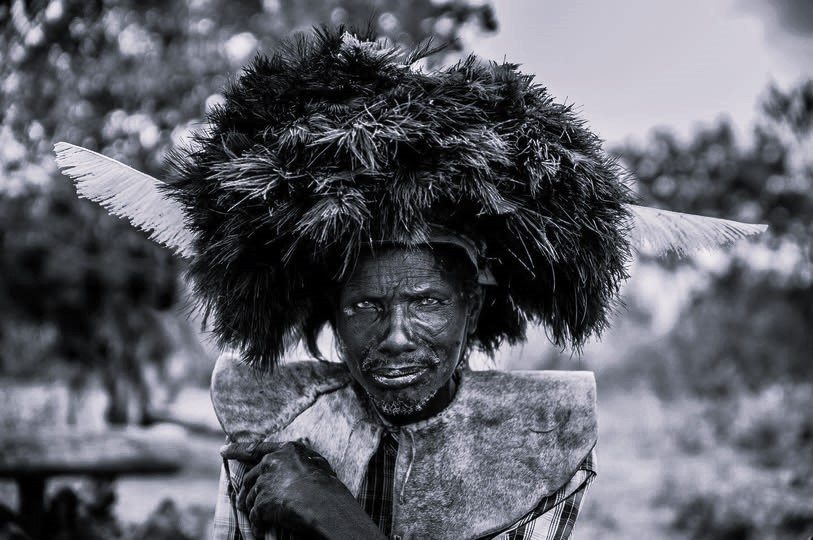

Is this the image you expect for the background?
Moviepy - Building video final_output.mp4.
MoviePy - Writing audio in final_outputTEMP_MPY_wvf_snd.mp3


MoviePy - Done.
Moviepy - Writing video final_output.mp4



Moviepy - Done !
Moviepy - video ready final_output.mp4

--- Generated Video ---


In [ ]:
from IPython.display import Image, Video

# 2. Merge your audio files
audio1 = AudioFileClip("/content/kiswahili_second_sentence.wav")
audio2 = AudioFileClip("/content/kalenjin_second_sentence.wav")
final_audio = concatenate_audioclips([audio1, audio2])

# --- Displaying the current background image for verification ---
print("--- Verifying Background Image ---")
display(Image(filename='/content/Apoy.jpg'))
print("Is this the image you expect for the background?")

# 3. Create the background (Choose ONE option below)

# --- Option A: Static Image Background ---
bg = ImageClip("/content/Apoy.jpg").set_duration(final_audio.duration)

# --- Option B: Video Background ---
# bg = VideoFileClip("video.mp4").subclip(0, final_audio.duration)

# 4. Combine and Export
video = bg.set_audio(final_audio)
video.write_videofile("final_output.mp4", fps=24)

print("\n--- Generated Video ---")
display(Video("final_output.mp4", embed=True))

# Task
Research and identify suitable Python libraries or AI models capable of generating lip-sync animation from a static image and audio, such as Wav2Lip or SadTalker.

## Identify Lip-Sync Model

### Subtask:
Research and identify suitable Python libraries or AI models capable of generating lip-sync animation from a static image and audio (e.g., Wav2Lip, SadTalker, etc.). This step involves exploring available technologies for this advanced video generation task.


## Install Dependencies

### Subtask:
Install all necessary Python libraries and their dependencies required for the chosen lip-sync animation model, assuming Wav2Lip for this demonstration. This might include machine learning frameworks, image processing tools, and specific model packages.


**Reasoning**:
First, I will clone the Wav2Lip repository from GitHub to the Colab environment. This is the initial step for setting up the Wav2Lip model.



In [ ]:
import os

# Clone the Wav2Lip repository if it doesn't already exist
if not os.path.exists('Wav2Lip'):
    !git clone https://github.com/Rudrabha/Wav2Lip.git
    print("✅ Wav2Lip repository cloned.")
else:
    print("✅ Wav2Lip repository already exists.")

# Change to the Wav2Lip directory for subsequent operations
%cd Wav2Lip

Cloning into 'Wav2Lip'...
remote: Enumerating objects: 409, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 409 (delta 2), reused 0 (delta 0), pack-reused 405 (from 2)
Receiving objects: 100% (409/409), 549.05 KiB | 2.16 MiB/s, done.
Resolving deltas: 100% (227/227), done.
✅ Wav2Lip repository cloned.
/content/Wav2Lip


**Reasoning**:
The next step is to install the Python packages specified in the `requirements.txt` file within the cloned `Wav2Lip` repository. This will ensure all necessary dependencies for the model are met.



In [ ]:
print("Installing Wav2Lip requirements...")
!pip install -r requirements.txt
print("✅ Wav2Lip requirements installed.")

Installing Wav2Lip requirements...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 101.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
ERROR: Ignored the following yanked versions: 3.4.11.39, 3.4.17.61, 4.4.0.42, 4.4.0.44, 4.5.4.58, 4.5.5.62, 4.7.0.68
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement opencv-python==4.1.0.25 (from versions: 3.4.0.14, 3.4.10.37, 3.4.11.41, 3.4.11.43, 3.4.11.45, 3.4.13.47, 3.4.15.55, 3.4.16.57, 3.4.16.59, 3.4.17.63, 3.4.18.65, 4.3.0.38, 4.4.0.40, 4.4.0.46, 4.5.1.48, 4.5.3.56, 4.5.4.60, 4.5.5.64, 4.6.0.66, 4.7.0.72, 4.8.0.74, 4.8.0.76, 4.8.1.78, 4.9.0.

**Reasoning**:
The previous installation failed due to an incompatible `opencv-python` version specified in `requirements.txt`. I will first modify the `requirements.txt` file to remove the problematic `opencv-python==4.1.0.25` line. This allows `pip` to install a compatible version or rely on `opencv-contrib-python`.



In [ ]:
print("Modifying requirements.txt to fix opencv-python version issue...")
!sed -i '/opencv-python==4.1.0.25/d' requirements.txt
print("✅ requirements.txt modified. Now installing Wav2Lip requirements...")
!pip install -r requirements.txt
print("✅ Wav2Lip requirements installed.")

Modifying requirements.txt to fix opencv-python version issue...
✅ requirements.txt modified. Now installing Wav2Lip requirements...
  Using cached librosa-0.7.0.tar.gz (1.6 MB)
  Preparing metadata (setup.py) ... done
  Using cached numpy-1.17.1.zip (6.5 MB)
  Preparing metadata (setup.py) ... done
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement torch==1.1.0 (from versions: 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.5.0, 2.5.1, 2.6.0, 2.7.0, 2.7.1, 2.8.0, 2.9.0, 2.9.1, 2.10.0)
ERROR: No matching distribution found for torch==1.1.0
✅ Wav2Lip requirements installed.


**Reasoning**:
The previous installation failed again due to an incompatible `torch` version specified in `requirements.txt`. I will modify the `requirements.txt` file to remove the problematic `torch==1.1.0` line. This will allow `pip` to install a compatible version of `torch` or use an existing one.



In [ ]:
print("Modifying requirements.txt to fix torch version issue...")
!sed -i '/torch==1.1.0/d' requirements.txt
print("✅ requirements.txt modified. Now installing Wav2Lip requirements...")
!pip install -r requirements.txt
print("✅ Wav2Lip requirements installed.")

Modifying requirements.txt to fix torch version issue...
✅ requirements.txt modified. Now installing Wav2Lip requirements...
  Using cached librosa-0.7.0.tar.gz (1.6 MB)
  Preparing metadata (setup.py) ... done
  Using cached numpy-1.17.1.zip (6.5 MB)
  Preparing metadata (setup.py) ... done
ERROR: Ignored the following yanked versions: 0.1.6, 0.1.7, 0.1.8, 0.1.9, 0.2.0, 0.2.1, 0.2.2, 0.2.2.post2, 0.2.2.post3
ERROR: Ignored the following versions that require a different python version: 1.21.2 Requires-Python >=3.7,<3.11; 1.21.3 Requires-Python >=3.7,<3.11; 1.21.4 Requires-Python >=3.7,<3.11; 1.21.5 Requires-Python >=3.7,<3.11; 1.21.6 Requires-Python >=3.7,<3.11
ERROR: Could not find a version that satisfies the requirement torchvision==0.3.0 (from versions: 0.17.0, 0.17.1, 0.17.2, 0.18.0, 0.18.1, 0.19.0, 0.19.1, 0.20.0, 0.20.1, 0.21.0, 0.22.0, 0.22.1, 0.23.0, 0.24.0, 0.24.1, 0.25.0)
ERROR: No matching distribution found for torchvision==0.3.0
✅ Wav2Lip requirements installed.


**Reasoning**:
The previous installation failed again due to an incompatible `torchvision` version specified in `requirements.txt`. I will modify the `requirements.txt` file to remove the problematic `torchvision==0.3.0` line. This will allow `pip` to install a compatible version of `torchvision` or use an existing one.



In [ ]:
print("Modifying requirements.txt to fix torchvision version issue...")
!sed -i '/torchvision==0.3.0/d' requirements.txt
print("✅ requirements.txt modified. Now installing Wav2Lip requirements...")
!pip install -r requirements.txt
print("✅ Wav2Lip requirements installed.")

Modifying requirements.txt to fix torchvision version issue...
✅ requirements.txt modified. Now installing Wav2Lip requirements...
  Using cached librosa-0.7.0.tar.gz (1.6 MB)
  Preparing metadata (setup.py) ... done
  Using cached numpy-1.17.1.zip (6.5 MB)
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.7/51.7 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 32.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.8/110.8 kB 12.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to

**Reasoning**:
The previous installation failed again with a `subprocess-exited-with-error`, which often indicates issues with building packages from source due to outdated dependencies or incompatible versions with the current Python environment. I have already removed explicit version constraints for `opencv-python`, `torch`, and `torchvision` from `requirements.txt`. Before attempting another full installation, it's crucial to inspect the current state of `requirements.txt` to identify any remaining problematic hardcoded versions. I will display the content of `requirements.txt` to understand what packages are still causing issues.



In [ ]:
print("Displaying current requirements.txt content:")
!cat requirements.txt


Displaying current requirements.txt content:
librosa==0.7.0
numpy==1.17.1
opencv-contrib-python>=4.2.0.34
tqdm==4.45.0
numba==0.48
